In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [2]:
file_path = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'
telco = pd.read_csv(file_path)
telco.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:

#As a consultant, identify the key drivers of churn,
#quantify the revenue at risk, and recommend a
#targeted retention strategy that maximizes ROI given a limited budget."


### Data Cleaning

In [5]:
# Check for duplicate rows
duplicates_before = telco.duplicated().sum()
print(f"Number of duplicate rows before cleaning: {duplicates_before}")

# Remove duplicate rows
telco.drop_duplicates(inplace=True)

duplicates_after = telco.duplicated().sum()
print(f"Number of duplicate rows after cleaning: {duplicates_after}")

Number of duplicate rows before cleaning: 0
Number of duplicate rows after cleaning: 0


In [6]:
# Replace blank spaces in 'TotalCharges' with NaN and convert to numeric
telco['TotalCharges'] = telco['TotalCharges'].replace(' ', pd.NA)
telco['TotalCharges'] = pd.to_numeric(telco['TotalCharges'])

# Check for missing values after conversion
missing_totalcharges = telco['TotalCharges'].isnull().sum()
print(f"Missing values in 'TotalCharges' after conversion: {missing_totalcharges}")

Missing values in 'TotalCharges' after conversion: 11


In [7]:
# Check for missing values in the entire DataFrame
missing_values_before_drop = telco.isnull().sum().sum()
print(f"Total missing values before dropping rows: {missing_values_before_drop}")

# Drop rows with any missing values
telco.dropna(inplace=True)

missing_values_after_drop = telco.isnull().sum().sum()
print(f"Total missing values after dropping rows: {missing_values_after_drop}")
print(f"\nShape of DataFrame after cleaning: {telco.shape}")

# Display general information about the cleaned DataFrame
telco.info()

Total missing values before dropping rows: 11
Total missing values after dropping rows: 0

Shape of DataFrame after cleaning: (7032, 21)
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  Stre

In [8]:
churn_rate = round((telco['Churn'] == 'Yes').mean() * 100, 1)

#churn rate per contract type
churn_contract =(telco.groupby('Contract')['Churn'].value_counts(normalize=True)*100).round(1)

print(f"the churn rate is {churn_rate}%")

print(churn_contract)


the churn rate is 26.6%
Contract        Churn
Month-to-month  No       57.3
                Yes      42.7
One year        No       88.7
                Yes      11.3
Two year        No       97.2
                Yes       2.8
Name: proportion, dtype: float64


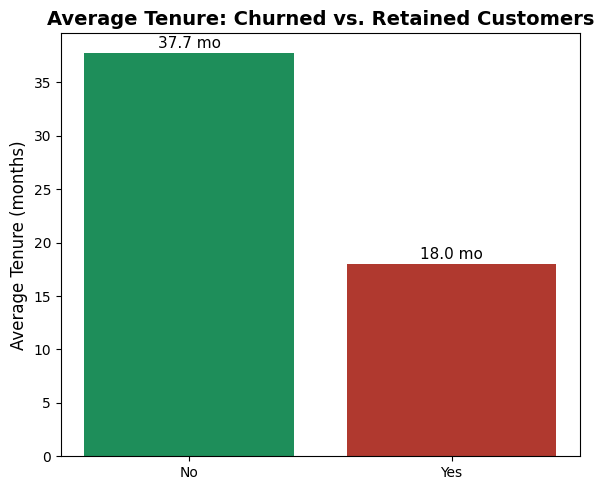

In [9]:
import matplotlib.pyplot as plt

tenure_by_churn = telco.groupby('Churn')['tenure'].mean().round(1)

plt.figure(figsize=(6, 5))
bars = plt.bar(tenure_by_churn.index, tenure_by_churn.values,
                color=['#1E8E5A', '#B0392F'])  # green for No, red for Yes

plt.ylabel('Average Tenure (months)', fontsize=12)
plt.title('Average Tenure: Churned vs. Retained Customers', fontsize=14, fontweight='bold')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
              f'{height} mo', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('tenure_by_churn.png', dpi=200, bbox_inches='tight')
plt.show()

In [10]:
#Does how customers pay relate to churn?
(telco.groupby('PaymentMethod')['Churn'].value_counts(normalize=True)*100).round(1)

PaymentMethod              Churn
Bank transfer (automatic)  No       83.3
                           Yes      16.7
Credit card (automatic)    No       84.7
                           Yes      15.3
Electronic check           No       54.7
                           Yes      45.3
Mailed check               No       80.8
                           Yes      19.2
Name: proportion, dtype: float64

In [11]:
#tenure and drop rate
telco.groupby('Churn')['tenure'].mean()


,tenure
Churn,
No,37.650010
Yes,17.979133


In [12]:
#does having tech support cause people to churn less

(telco.groupby('TechSupport')['Churn'].apply(lambda x: (x == 'Yes').mean())*100).round(1)

,Churn
TechSupport,
No,41.6
No internet service,7.4
Yes,15.2


In [13]:
model_telco = telco.copy()
model_telco = model_telco.drop(columns=['customerID'])

# Turn Churn into 0/1 first for easier analysis purposes 1=True 0=False
model_telco['Churn'] = (model_telco['Churn'] == 'Yes').astype(int)

# One-hot encode everything else that's still text
model_telco = pd.get_dummies(model_telco, drop_first=True)

model_telco.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [14]:
X = model_telco.drop(columns=['Churn'])
y = model_telco['Churn']

print(X.shape)
print(y.shape)

(7032, 30)
(7032,)


Train accuracy: 0.7521332791548151
Test accuracy: 0.7279620853080568


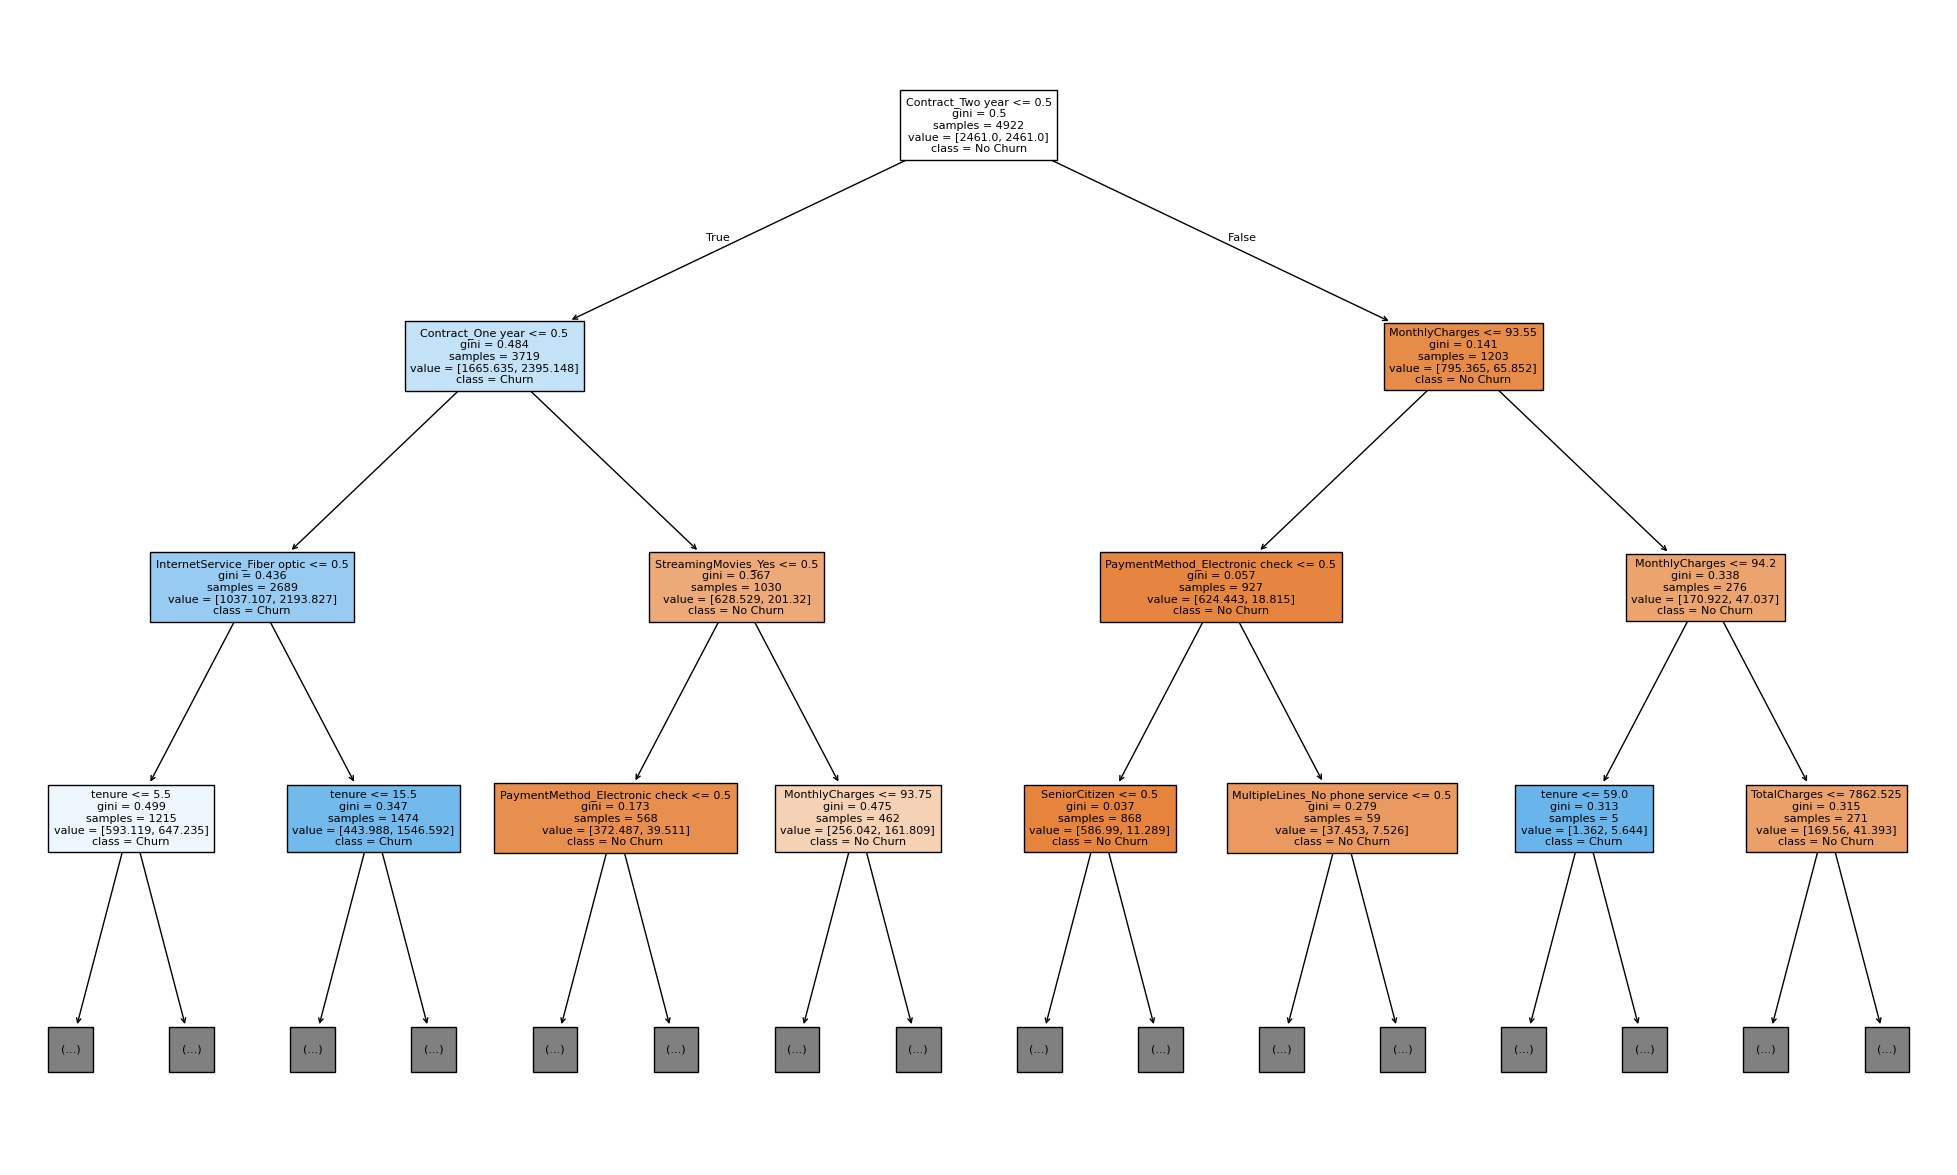

In [15]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# A shallow tree just for visualization/interpretability (not your main model)
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
tree_model.fit(X_train, y_train)

print('Train accuracy:', tree_model.score(X_train, y_train))
print('Test accuracy:', tree_model.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(25, 15))
plot_tree(tree_model, filled=True, feature_names=X.columns,
          class_names=['No Churn', 'Churn'], max_depth=3, fontsize=8)
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train the model
rf_model.fit(X_train, y_train)

# Get feature importances
feature_importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
})

# Sort by importance and display the top N features
top_features = feature_importances.sort_values(by='importance', ascending=False).head(20)

print("Top 20 features driving churn:")
print(top_features)

Top 20 features driving churn:
                                  feature  importance
1                                  tenure    0.172762
3                            TotalCharges    0.168929
2                          MonthlyCharges    0.156982
25                      Contract_Two year    0.056856
10            InternetService_Fiber optic    0.040950
28         PaymentMethod_Electronic check    0.033203
24                      Contract_One year    0.032165
13                     OnlineSecurity_Yes    0.029276
4                             gender_Male    0.025364
19                        TechSupport_Yes    0.023957
26                   PaperlessBilling_Yes    0.023166
5                             Partner_Yes    0.021954
15                       OnlineBackup_Yes    0.019366
6                          Dependents_Yes    0.019193
0                           SeniorCitizen    0.018673
17                   DeviceProtection_Yes    0.017764
9                       MultipleLines_Yes    0.0176

In [17]:
telco_test = X_test.copy()
telco_test['actual_churn'] = y_test
telco_test['churn_risk'] = tree_model.predict_proba(X_test)[:, 1]
high_risk = telco_test[telco_test['churn_risk'] > 0.5]
print("Number of high-risk customers:", len(high_risk))

Number of high-risk customers: 889


In [18]:
high_risk_charges = telco.loc[high_risk.index, 'MonthlyCharges']

monthly_revenue_at_risk = high_risk_charges.sum()
annual_revenue_at_risk = monthly_revenue_at_risk * 12

print(f"Monthly revenue at risk: {monthly_revenue_at_risk}")
print(f"Annual revenue at risk: {annual_revenue_at_risk}")


Monthly revenue at risk: 65585.25
Annual revenue at risk: 787023.0


In [19]:
len(telco)

7032

In [20]:
len(X_test)

2110

In [21]:
# Predict churn risk for all customers and not just the test set
model_telco_all = model_telco.drop(columns=['Churn'])
telco['churn_risk'] = tree_model.predict_proba(model_telco_all)[:, 1]

high_risk_all = telco[telco['churn_risk'] > 0.5]
print("Number of high-risk customers (entire dataset):", len(high_risk_all))

monthly_revenue_at_risk_all = high_risk_all['MonthlyCharges'].sum()
annual_revenue_at_risk_all = monthly_revenue_at_risk_all * 12
print(f"Monthly revenue at risk (full dataset): ${monthly_revenue_at_risk_all.round()}")
print(f"Annual revenue at risk (full dataset): ${annual_revenue_at_risk_all.round()}")

Number of high-risk customers (entire dataset): 2875
Monthly revenue at risk (full dataset): $212602.0
Annual revenue at risk (full dataset): $2551226.0


In [22]:
# this is for k means, group into clusters and identify shared traits
segment_features = telco[['tenure', 'MonthlyCharges', 'TotalCharges', 'churn_risk']].copy()

# Handle any missing TotalCharges and replace things that cant be covnerted into number with NaN
segment_features['TotalCharges'] = pd.to_numeric(segment_features['TotalCharges'], errors='coerce')
segment_features['TotalCharges'] = segment_features['TotalCharges'].fillna(0)

segment_features.head()


,tenure,MonthlyCharges,TotalCharges,churn_risk
0,1,29.85,29.85,0.664306
1,34,56.95,1889.50,0.068341
2,2,53.85,108.15,0.664306
3,45,42.30,1840.75,0.068341
4,2,70.70,151.65,0.865114


In [23]:
#scale the features to make them comparable

scaler = StandardScaler()
segment_scaled = scaler.fit_transform(segment_features)

#actual K means

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
segment_features['cluster'] = kmeans.fit_predict(segment_scaled)

segment_features['cluster'].value_counts()

,count
cluster,
2,1870
1,1842
0,1773
3,1547


In [24]:

"""Cluster 0 - Loyal Budget: long tenure, low spend, low risk. No action needed. Cluster 1 - Loyal High-Value: long tenure, high spend, low risk. Light loyalty perks. Cluster 2 - New & High-Risk: brand new, high risk. TOP PRIORITY. Cluster 3 - Mid-Tenure Elevated Risk: highest spend, moderate risk. 2nd priority."""
segment_features.groupby('cluster')[['tenure', 'MonthlyCharges', 'TotalCharges', 'churn_risk']].mean().round(1)

,tenure,MonthlyCharges,TotalCharges,churn_risk
cluster,,,,
0,9.8,37.5,390.7,0.4
1,59.9,93.5,5598.8,0.3
2,14.5,84.7,1264.4,0.8
3,47.4,37.8,1736.3,0.1


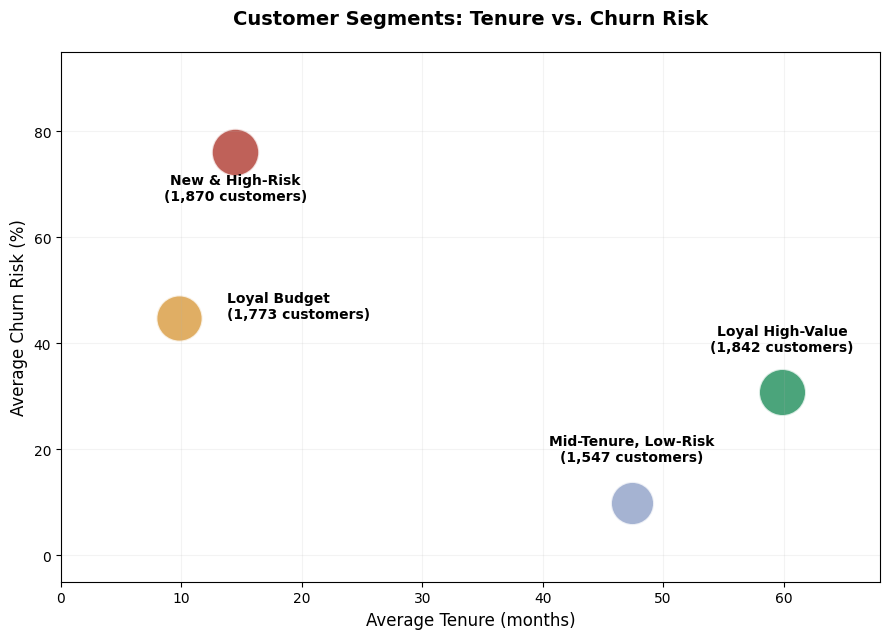

In [25]:
import matplotlib.pyplot as plt

cluster_avg = segment_features.groupby('cluster')[['tenure', 'churn_risk']].mean()
cluster_counts = segment_features['cluster'].value_counts()

cluster_labels = {
    0: 'Loyal Budget',
    1: 'Loyal High-Value',
    2: 'New & High-Risk',
    3: 'Mid-Tenure, Low-Risk'
}
cluster_colors = {
    0: '#D99A3D',
    1: '#1E8E5A',
    2: '#B0392F',
    3: '#8FA0C7'
}
# custom label offsets per cluster: (x_offset, y_offset, alignment)
label_offsets = {
    0: (35, 0, 'left'),      # Loyal Budget -> push label to the right instead of up
    1: (0, 30, 'center'),
    2: (0, -35, 'center'),   # New & High-Risk -> push label BELOW the point instead of above
    3: (0, 30, 'center'),
}

plt.figure(figsize=(9, 6.5))

for cluster_num in sorted(segment_features['cluster'].unique()):
    tenure = cluster_avg.loc[cluster_num, 'tenure']
    risk = cluster_avg.loc[cluster_num, 'churn_risk'] * 100
    count = cluster_counts[cluster_num]

    plt.scatter(
        tenure, risk,
        s=count / 1.6,
        color=cluster_colors[cluster_num],
        alpha=0.8,
        edgecolors='white',
        linewidths=1.5
    )
    xoff, yoff, ha = label_offsets[cluster_num]
    plt.annotate(
        f"{cluster_labels[cluster_num]}\n({count:,} customers)",
        (tenure, risk),
        textcoords="offset points",
        xytext=(xoff, yoff),
        ha=ha,
        fontsize=10,
        fontweight='bold'
    )

plt.xlabel('Average Tenure (months)', fontsize=12)
plt.ylabel('Average Churn Risk (%)', fontsize=12)
plt.title('Customer Segments: Tenure vs. Churn Risk', fontsize=14, fontweight='bold', pad=20)
plt.ylim(-5, 95)   # extra headroom so the top label doesn't hit the title
plt.xlim(0, 68)    # extra room on the left so "Loyal Budget" doesn't hit the axis
plt.grid(alpha=0.15)
plt.tight_layout()

plt.savefig('kmeans_bubble.png', dpi=200, bbox_inches='tight')
plt.show()

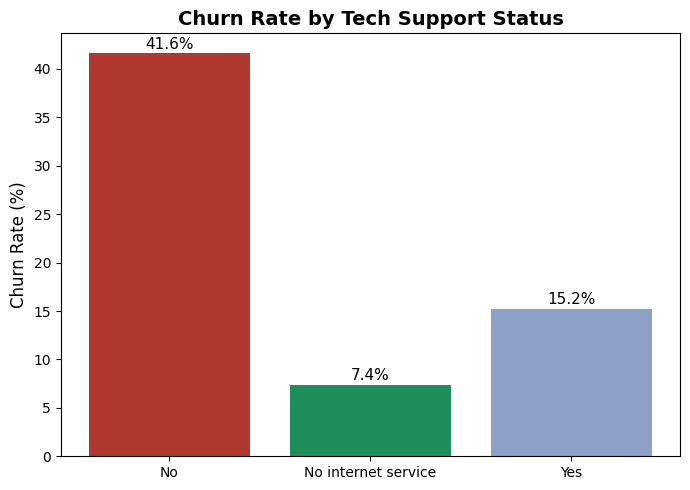

In [26]:
import matplotlib.pyplot as plt

tech_support_churn = (telco.groupby('TechSupport')['Churn']
                       .apply(lambda x: (x == 'Yes').mean() * 100)
                       .round(1))

plt.figure(figsize=(7, 5))
bars = plt.bar(tech_support_churn.index, tech_support_churn.values,
                color=['#B0392F', '#1E8E5A', '#8FA0C7'])

plt.ylabel('Churn Rate (%)', fontsize=12)
plt.title('Churn Rate by Tech Support Status', fontsize=14, fontweight='bold')

# add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
              f'{height}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('churn_by_tech_support.png', dpi=200, bbox_inches='tight')
plt.show()